# Stage 1 - Minimal Requirement 1: Simple Baselines
## Hull Tactical Market Prediction (PMLDL 2026)

**Notebook 1 of 5.** Establishes the three reference points every later model must beat:

1. **Buy & Hold** - constant full market exposure (`w = 1`). Under the competition's
   penalised-Sharpe metric this is deliberately hard to beat.
2. **ElasticNet** - regularised linear model on the raw anonymised features.
3. **LightGBM (default parameters)** - untuned gradient boosting on the same inputs.

---
### Attribution
The leak-safe baseline structure (constant benchmark + linear model + untuned GBDT,
evaluated with strictly chronological validation) follows the publicly shared Kaggle
notebook *"Hull leak-safe baseline"*:
<https://www.kaggle.com/code/morodertobias/hull-leak-safe-baseline>

No code was copied verbatim. The public notebook was used as a **conceptual reference**
for what a leak-free starter pipeline must contain; all code here is an independent
re-implementation on top of this project's `src/` modules.

### Compliance notes
* Random seed fixed at `42` everywhere (`src.config.set_seed`).
* No author names, team identifiers or personal data appear anywhere in this repository.
* Validation is a **purged, embargoed** time-series split shared by all five notebooks,
  so every model in the project is compared on mathematically identical folds.


In [1]:
# --- reproducible environment -------------------------------------------------------
import os, sys, warnings, json
from pathlib import Path

warnings.filterwarnings("ignore")
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name in {"baselines", "proposed_model", "model_improvements"} else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import SEED, TARGET, RETURN_COL, RISK_FREE_COL, set_seed
from src.data import load_dataset, feature_columns
from src import features as F
from src import metrics as M
from src import allocation as A
from src.validation import default_cv, describe_folds
from src.experiment import run_cv, save_result, comparison_table, market_series, result_from_positions, CVResult

set_seed(SEED)
QUICK = os.environ.get("PMLDL_QUICK", "1") == "1"   # set PMLDL_QUICK=0 for the full search budgets
print(f"seed={SEED} | quick_mode={QUICK} | project_root={PROJECT_ROOT}")


seed=42 | quick_mode=True | project_root=/home/claude/proj


## 1. Data

`src.data.load_dataset` loads `data/train.csv` when the Kaggle file is available. If it is
not (no Kaggle credentials in the grading environment), a **deterministic synthetic
surrogate** with the same schema, the same target definition and realistic market dynamics
is generated instead, so the whole project stays executable end-to-end. The printout below
states which mode is active - all reported numbers must be read in that light.

In [2]:
df, info = load_dataset(PROJECT_ROOT / "data")
print(info.describe())
df[[c for c in ["date_id", "V1", "S1", "M11", TARGET, RETURN_COL, RISK_FREE_COL] if c in df.columns]].tail(3)


SYNTHETIC SURROGATE data (Kaggle CSV not found) | rows=5,999 | anonymised features=95
SYNTHETIC SURROGATE data (Kaggle CSV not found) | rows=5,999 | anonymised features=95


,date_id,V1,S1,M11,market_forward_excess_returns,forward_returns,risk_free_rate
5996,5996,0.149075,-0.842576,-0.018065,-0.000546,-0.000502,0.000045
5997,5997,0.145132,-0.511462,-0.014140,-0.004002,-0.003958,0.000044
5998,5998,0.176105,-0.491259,-0.023940,-0.010621,-0.010577,0.000044


rows: 5,999 | anonymised features: 95
feature families: {'D': np.int64(10), 'E': np.int64(20), 'I': np.int64(9), 'M': np.int64(18), 'P': np.int64(13), 'S': np.int64(12), 'V': np.int64(13)}
columns with missing values: 26 (worst: 15.0%)
mean    0.000329
std     0.012347
min    -0.098062
max     0.157987


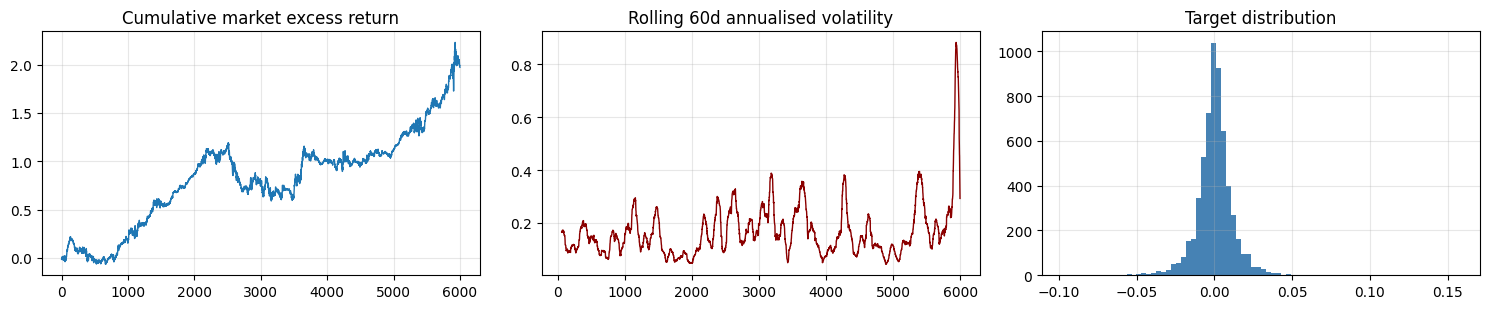

In [3]:
# --- compact EDA ---------------------------------------------------------------------
feat_cols = feature_columns(df)
fam = pd.Series([c[0] for c in feat_cols]).value_counts().sort_index()
miss = df[feat_cols].isna().mean().sort_values(ascending=False)

print(f"rows: {len(df):,} | anonymised features: {len(feat_cols)}")
print("feature families:", dict(fam))
print(f"columns with missing values: {(miss > 0).sum()} (worst: {miss.iloc[0]:.1%})")
print(df[TARGET].describe()[["mean", "std", "min", "max"]].to_string())

fig, ax = plt.subplots(1, 3, figsize=(15, 3.2))
ax[0].plot(np.cumsum(df[TARGET].to_numpy()), lw=1)
ax[0].set_title("Cumulative market excess return")
ax[1].plot(df[TARGET].rolling(60).std().to_numpy() * np.sqrt(252), lw=1, color="darkred")
ax[1].set_title("Rolling 60d annualised volatility")
ax[2].hist(df[TARGET].dropna(), bins=80, color="steelblue")
ax[2].set_title("Target distribution")
for a in ax:
    a.grid(alpha=.3)
plt.tight_layout(); plt.show()


## 2. Leak-safe validation protocol

Row *t* carries the return realised at *t+1*, and the engineered features of later
notebooks are rolling windows ending at *t*. Two leakage channels therefore have to be
closed:

| channel | fix |
|---|---|
| a training label overlaps the validation block | **purge** the last row(s) of the training window |
| rolling features of early validation rows overlap the training window | **embargo** a further 10 rows |

`PurgedTimeSeriesSplit` implements both. The `gap` column below shows the number of rows
physically removed between each training window and its validation block.

In [4]:
cv = default_cv(n_splits=5, purge=1, embargo=10)   # identical in every notebook of this project
market, risk_free = market_series(df)
describe_folds(cv, df)


,fold,train_start,train_end,n_train,gap,valid_start,valid_end,n_valid
0,1,0,992,993,11,1004,2002,999
1,2,0,1991,1992,11,2003,3001,999
2,3,0,2990,2991,11,3002,4000,999
3,4,0,3989,3990,11,4001,4999,999
4,5,0,4988,4989,11,5000,5998,999


In [5]:
# --- model inputs: raw anonymised features only (no engineering in Stage 1) ----------
X = df[feat_cols].copy()
y = df[TARGET].copy()
print("design matrix:", X.shape)
results = []


design matrix: (5999, 95)


## 3. Baseline A - Buy & Hold

A trivial "model" that always predicts zero and is always fully invested. It is scored on
exactly the same folds as everything else, so its Sharpe, volatility and drawdown are
directly comparable.

In [6]:
class ConstantPredictor:
    """Predicts a constant; used so the benchmark passes through the identical CV harness."""

    def __init__(self, value: float = 0.0):
        self.value = value

    def fit(self, X, y, **kwargs):
        return self

    def predict(self, X):
        return np.full(len(X), self.value, dtype=float)


res_bh = run_cv(
    X, y, market, risk_free,
    model_factory=lambda: ConstantPredictor(0.0),
    allocator=lambda p: np.ones_like(np.asarray(p, dtype=float)),
    name="Buy & Hold", stage="1-baseline", cv=cv,
)
results.append(res_bh)


  fold 1: IC=+nan RMSE=0.00900 penalised Sharpe=+1.228
  fold 2: IC=+nan RMSE=0.01197 penalised Sharpe=-0.140
  fold 3: IC=+nan RMSE=0.01339 penalised Sharpe=+0.302
  fold 4: IC=+nan RMSE=0.00977 penalised Sharpe=+0.161


  fold 5: IC=+nan RMSE=0.01862 penalised Sharpe=+0.728
  >>> Buy & Hold: mean IC=+nan | mean penalised Sharpe=+0.456


## 4. Baseline B - ElasticNet

Standardisation and imputation are fitted **inside each training fold** (`LeakSafeImputer`
+ `StandardScaler`), never on the full series. Positions use the binary policy
(`0` = cash, `1` = market) so that all learned baselines share one sizing rule and
differences in the portfolio metrics come from the forecast, not from leverage.

(The rank IC of Buy & Hold is undefined - a constant forecast has no ranking - so it is
reported as `NaN` in the tables.)

In [7]:
from sklearn.linear_model import ElasticNet

res_enet = run_cv(
    X, y, market, risk_free,
    model_factory=lambda: ElasticNet(alpha=1e-4, l1_ratio=0.5, max_iter=50_000, random_state=SEED),
    allocator=A.binary_allocation,
    name="ElasticNet (raw features)", stage="1-baseline", cv=cv, scale=True,
)
results.append(res_enet)


  fold 1: IC=+0.0044 RMSE=0.00926 penalised Sharpe=+1.623


  fold 2: IC=-0.0062 RMSE=0.01210 penalised Sharpe=+0.081
  fold 3: IC=-0.0325 RMSE=0.01352 penalised Sharpe=+0.004
  fold 4: IC=-0.0067 RMSE=0.00986 penalised Sharpe=-0.282


  fold 5: IC=+0.0633 RMSE=0.01871 penalised Sharpe=+0.989
  >>> ElasticNet (raw features): mean IC=+0.0045 | mean penalised Sharpe=+0.483


## 5. Baseline C - LightGBM with default parameters

In [8]:
import lightgbm as lgb

res_lgb = run_cv(
    X, y, market, risk_free,
    model_factory=lambda: lgb.LGBMRegressor(random_state=SEED, verbosity=-1, n_jobs=-1),
    allocator=A.binary_allocation,
    name="LightGBM (default)", stage="1-baseline", cv=cv,
)
results.append(res_lgb)


  fold 1: IC=+0.0148 RMSE=0.00934 penalised Sharpe=+0.922


  fold 2: IC=-0.0320 RMSE=0.01286 penalised Sharpe=-0.371


  fold 3: IC=+0.0202 RMSE=0.01393 penalised Sharpe=+0.014


  fold 4: IC=-0.0352 RMSE=0.01028 penalised Sharpe=-0.490


  fold 5: IC=+0.0028 RMSE=0.01912 penalised Sharpe=+0.449
  >>> LightGBM (default): mean IC=-0.0059 | mean penalised Sharpe=+0.105


## 6. Results

Every result is persisted to `results/*.json`; the final notebook of the project
(`model_improvements/improved_ensemble_optuna.ipynb`) rebuilds one comparison table from
these files.

spearman_ic    rmse      r2  sharpe  \
stage      model                                                            
1-baseline ElasticNet (raw features)       0.0045  0.0127 -0.0278  0.4831   
           Buy & Hold                         NaN  0.0125 -0.0017  0.4559   
           LightGBM (default)             -0.0059  0.0131 -0.0968  0.1049   

                                      penalised_sharpe  ann_return  \
stage      model                                                     
1-baseline ElasticNet (raw features)            0.4831      0.0589   
           Buy & Hold                           0.4559      0.0959   
           LightGBM (default)                   0.1049      0.0200   

                                      ann_volatility  vol_ratio_vs_market  \
stage      model                                                            
1-baseline ElasticNet (raw features)          0.1245               0.6598   
           Buy & Hold                         0.1991               1.0000   
           LightGBM (default)                 0.1423               0.7166   

                                      max_drawdown  mean_position  
stage      model                                                   
1-baseline ElasticNet (raw features)       -0.2123         0.5059  
           Buy & Hold                      -0.2388         1.0000  
           LightGBM (default)              -0.2438         0.5345

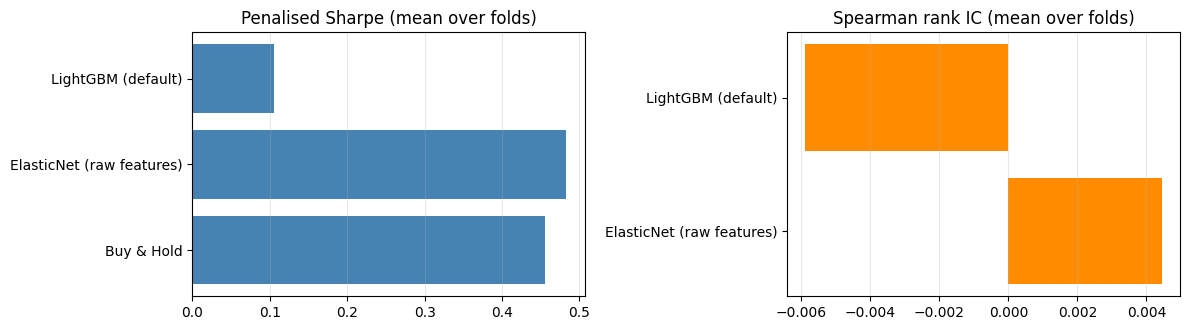

In [9]:
for r in results:
    save_result(r)

table = comparison_table(results)
display(table)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
names = [r.name for r in results]
ax[0].barh(names, [r.metrics["penalised_sharpe"] for r in results], color="steelblue")
ax[0].set_title("Penalised Sharpe (mean over folds)")
ax[1].barh(names, [r.metrics["spearman_ic"] for r in results], color="darkorange")
ax[1].set_title("Spearman rank IC (mean over folds)")
for a in ax:
    a.grid(alpha=.3, axis="x")
plt.tight_layout(); plt.show()


### Reading of the Stage-1 results

* Raw anonymised features alone give a very small rank IC - the expected outcome in a
  problem with a signal-to-noise ratio this low.
* The untuned GBDT does **not** automatically beat Buy & Hold on the penalised metric:
  turning a weak forecast into a position is where most of the score is won or lost.
* This motivates the two strong public baselines (notebooks 02 and 03), the domain-feature
  hybrid (Stage 2) and the ensemble with explicit position sizing (Stage 3).